In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

# Import dataset

In [2]:
# Chargement API KEYS
load_dotenv()

API_KEY_S3 = os.environ["AWS_ACCESS_KEY_ID"]
API_SECRET_KEY_S3 = os.environ["AWS_SECRET_ACCESS_KEY"]

bucket_name = "renergies99-lead-bucket"
s3_prefix = "public"

In [3]:
df = pd.read_csv(
    "s3://renergies99-lead-bucket/public/prod/eCO2mix_RTE_Auvergne-Rhone-Alpes.csv",
    index_col=0,
    storage_options={
        "key": API_KEY_S3,
        "secret": API_SECRET_KEY_S3,
    }
)

C:\Users\nouan\AppData\Local\Temp\ipykernel_18944\1416584072.py:1: DtypeWarning: Columns (12,13,14,15,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [4]:
df.head()

,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,...,TCO Nucléaire (%),TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%)
Périmètre,,,,,,,,,,,,,,,,,,,,,
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,00:00,8586.0,156.0,10710.0,66.0,0.0,3096.0,-166.0,...,124.74,78.92,0.77,11.81,0.0,0.0,36.06,26.25,1.55,71.12
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,00:30,8373.0,179.0,10622.0,64.0,0.0,2977.0,-163.0,...,126.86,78.28,0.76,11.45,0.0,0.0,35.55,25.24,1.45,64.71
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,01:00,8134.0,181.0,10652.0,58.0,0.0,2667.0,-163.0,...,130.96,78.50,0.71,10.38,0.0,0.0,32.79,22.61,1.49,64.71
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,01:30,8130.0,179.0,10662.0,54.0,0.0,2592.0,-163.0,...,131.14,78.57,0.66,9.66,0.0,0.0,31.88,21.98,1.50,65.24
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,02:00,8102.0,181.0,10600.0,42.0,0.0,2827.0,-165.0,...,130.83,78.11,0.52,7.51,0.0,0.0,34.89,23.97,1.48,64.17


In [5]:
df.shape

(92448, 66)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92448 entries, Auvergne-Rhône-Alpes to Auvergne-Rhône-Alpes
Data columns (total 66 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Nature                                                               92448 non-null  object 
 1   Date                                                                 92448 non-null  object 
 2   Heures                                                               92448 non-null  object 
 3   Consommation                                                         92448 non-null  float64
 4   Thermique                                                            92448 non-null  float64
 5   Nucléaire                                                            92448 non-null  float64
 6   Eolien                                                               9244

In [7]:
df.describe(include="all")

,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,...,TCO Nucléaire (%),TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%)
count,92448,92448,92448,92448.000000,92448.000000,92448.000000,92448.000000,92448.000000,92448.000000,92448.000000,...,92447.000000,92448.000000,92447.000000,92448.000000,92447.000000,92448.000000,92447.000000,92448.000000,92447.000000,92448.000000
unique,3,1926,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Données définitives,2026-05-11,00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,52560,48,1926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,7149.753624,191.554279,9249.107682,163.041083,304.507658,3116.751893,-432.395974,...,131.399233,68.158494,2.311623,23.124968,4.357440,14.327332,44.075465,27.168192,1.645820,58.986564
std,NaN,NaN,NaN,1453.199002,209.658917,1874.231980,123.685582,479.145471,1288.089347,576.662255,...,24.239874,13.811601,1.773606,17.566049,7.019531,21.239387,17.224899,11.218654,0.402671,6.942979
min,NaN,NaN,NaN,0.000000,0.000000,3433.000000,0.000000,0.000000,588.000000,-2580.000000,...,57.880000,25.300000,0.000000,0.000000,0.000000,0.000000,8.470000,5.130000,0.440000,21.160000
25%,NaN,NaN,NaN,6037.000000,11.000000,7884.750000,62.000000,0.000000,2161.000000,-806.000000,...,114.340000,58.107500,0.890000,8.760000,0.000000,0.000000,31.270000,18.850000,1.340000,55.500000
50%,NaN,NaN,NaN,6998.000000,112.000000,9144.000000,135.000000,5.000000,2988.000000,-43.000000,...,128.470000,67.380000,1.900000,19.120000,0.060000,0.230000,42.050000,26.060000,1.600000,60.210000
75%,NaN,NaN,NaN,8080.000000,368.000000,10646.000000,237.000000,489.000000,3881.000000,-12.000000,...,146.160000,78.450000,3.340000,33.670000,6.700000,24.640000,55.110000,33.770000,1.910000,63.830000


# Vue générale

In [8]:
# Nombre de  valeurs manquantes
valeurs_manquantes = df.isna().sum()
valeurs_manquantes

Nature                 0
Date                   0
Heures                 0
Consommation           0
Thermique              0
                      ..
TCH Solaire (%)        0
TCO Hydraulique (%)    1
TCH Hydraulique (%)    0
TCO Bioénergies (%)    1
TCH Bioénergies (%)    0
Length: 66, dtype: int64

In [9]:
# Pourcentage de valeurs manquantes
valeurs_manquantes_pourcent = (df.isna().sum() / df.shape[0]) * 100
valeurs_manquantes_pourcent

Nature                 0.000000
Date                   0.000000
Heures                 0.000000
Consommation           0.000000
Thermique              0.000000
                         ...   
TCH Solaire (%)        0.000000
TCO Hydraulique (%)    0.001082
TCH Hydraulique (%)    0.000000
TCO Bioénergies (%)    0.001082
TCH Bioénergies (%)    0.000000
Length: 66, dtype: float64

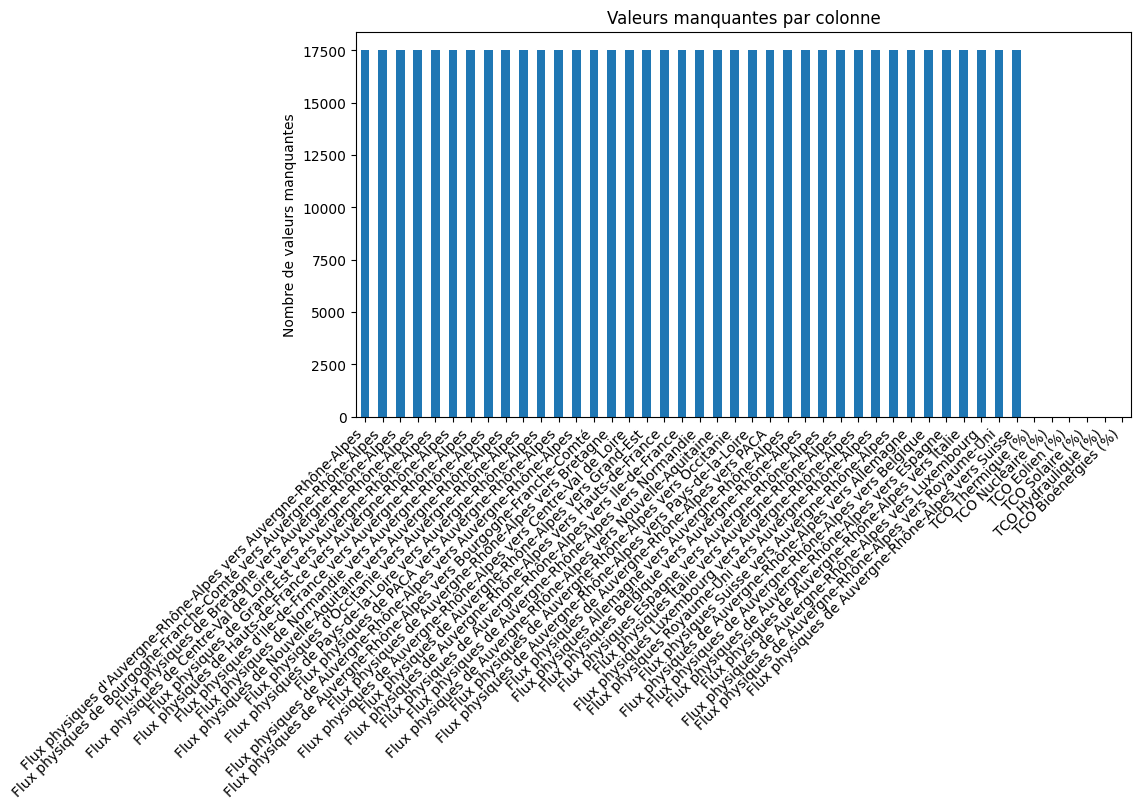

In [10]:
valeurs_manquantes_graph = valeurs_manquantes[valeurs_manquantes > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
# Prise en charge si valeurs manquetes à 0
if valeurs_manquantes_graph.empty:
    ax = plt.gca()
    ax.text(0.5, 0.5, "Aucune valeur manquante",
            ha="center", va="center", fontsize=12)
    ax.axis("off")
else:
    valeurs_manquantes_graph.plot(kind="bar")
    plt.title("Valeurs manquantes par colonne")
    plt.ylabel("Nombre de valeurs manquantes")
    plt.xticks(rotation=45, ha="right")

plt.show()

In [11]:
# Vérification valeurs numériques float uniques
numeric_float = df.select_dtypes('float64')

for col in numeric_float.columns:
  print(f"Colonne {col} : ", numeric_float[col].nunique())

Colonne Consommation :  7116
Colonne Thermique :  725
Colonne Nucléaire :  8599
Colonne Eolien :  611
Colonne Solaire :  2426
Colonne Hydraulique :  6591
Colonne Pompage :  2331
Colonne Bioénergies :  84
Colonne Ech. physiques :  10250
Colonne TCO Thermique (%) :  995
Colonne TCH Thermique (%) :  4168
Colonne TCO Nucléaire (%) :  12151
Colonne TCH Nucléaire (%) :  6479
Colonne TCO Eolien (%) :  1000
Colonne TCH Eolien (%) :  4258
Colonne TCO Solaire (%) :  3450
Colonne TCH Solaire (%) :  7209
Colonne TCO Hydraulique (%) :  8338
Colonne TCH Hydraulique (%) :  5813
Colonne TCO Bioénergies (%) :  264
Colonne TCH Bioénergies (%) :  472


In [12]:
# Vérification valeurs numériques int uniques
numeric_int = df.select_dtypes('int64')

for col in numeric_int.columns:
  print(f"Colonne {col} : ", numeric_int[col].nunique())

In [13]:
# Vérification valeurs non numériques float uniques
non_numeric = df.select_dtypes('object')

for col in non_numeric.columns:
  print(f"Colonne {col} : ", non_numeric[col].nunique())

Colonne Nature :  3
Colonne Date :  1926
Colonne Heures :  48
Colonne Stockage batterie :  12
Colonne Déstockage batterie :  13
Colonne Eolien terrestre :  1117
Colonne Eolien offshore :  5
Colonne Flux physiques d'Auvergne-Rhône-Alpes vers Auvergne-Rhône-Alpes :  1
Colonne Flux physiques de Bourgogne-Franche-Comté vers Auvergne-Rhône-Alpes :  6446
Colonne Flux physiques de Bretagne vers Auvergne-Rhône-Alpes :  1
Colonne Flux physiques de Centre-Val de Loire vers Auvergne-Rhône-Alpes :  4483
Colonne Flux physiques de Grand-Est vers Auvergne-Rhône-Alpes :  1
Colonne Flux physiques de Hauts-de-France vers Auvergne-Rhône-Alpes :  1
Colonne Flux physiques d'Ile-de-France vers Auvergne-Rhône-Alpes :  1
Colonne Flux physiques de Normandie vers Auvergne-Rhône-Alpes :  1
Colonne Flux physiques de Nouvelle-Aquitaine vers Auvergne-Rhône-Alpes :  847
Colonne Flux physiques d'Occitanie vers Auvergne-Rhône-Alpes :  2601
Colonne Flux physiques de Pays-de-la-Loire vers Auvergne-Rhône-Alpes :  1
Colon

# Cleaning

In [14]:
df.replace(["ND", "n.d", "Na", "na", "-", ""], np.nan, inplace=True)

C:\Users\nouan\AppData\Local\Temp\ipykernel_18944\2168416036.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["ND", "n.d", "Na", "na", "-", ""], np.nan, inplace=True)


In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [16]:
df.shape

(92448, 66)

In [17]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 92448 entries, Auvergne-Rhône-Alpes to Auvergne-Rhône-Alpes
Data columns (total 66 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   nature                                                               92448 non-null  object 
 1   date                                                                 92448 non-null  object 
 2   heures                                                               92448 non-null  object 
 3   consommation                                                         92448 non-null  float64
 4   thermique                                                            92448 non-null  float64
 5   nucléaire                                                            92448 non-null  float64
 6   eolien                                                               9244

In [18]:
df.head()

,nature,date,heures,consommation,thermique,nucléaire,eolien,solaire,hydraulique,pompage,...,tco_nucléaire_(%),tch_nucléaire_(%),tco_eolien_(%),tch_eolien_(%),tco_solaire_(%),tch_solaire_(%),tco_hydraulique_(%),tch_hydraulique_(%),tco_bioénergies_(%),tch_bioénergies_(%)
Périmètre,,,,,,,,,,,,,,,,,,,,,
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,00:00,8586.0,156.0,10710.0,66.0,0.0,3096.0,-166.0,...,124.74,78.92,0.77,11.81,0.0,0.0,36.06,26.25,1.55,71.12
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,00:30,8373.0,179.0,10622.0,64.0,0.0,2977.0,-163.0,...,126.86,78.28,0.76,11.45,0.0,0.0,35.55,25.24,1.45,64.71
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,01:00,8134.0,181.0,10652.0,58.0,0.0,2667.0,-163.0,...,130.96,78.50,0.71,10.38,0.0,0.0,32.79,22.61,1.49,64.71
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,01:30,8130.0,179.0,10662.0,54.0,0.0,2592.0,-163.0,...,131.14,78.57,0.66,9.66,0.0,0.0,31.88,21.98,1.50,65.24
Auvergne-Rhône-Alpes,Données définitives,2021-01-01,02:00,8102.0,181.0,10600.0,42.0,0.0,2827.0,-165.0,...,130.83,78.11,0.52,7.51,0.0,0.0,34.89,23.97,1.48,64.17


In [19]:
# Écriture directe du DataFrame cleaned sur S3
df.to_csv(
    "s3://renergies99-lead-bucket/public/prod/eCO2mix_RTE_Auvergne-Rhone-Alpes_cleaned.csv",
    index=False,
    storage_options={
        "key": API_KEY_S3,
        "secret": API_SECRET_KEY_S3,
    },
)